# Penguin 2D Partial Dependence Plots — P(female)

Three per-species logistic regression models, each visualized with a 2D PDP showing P(female) over `bill_depth_mm` (x) and `bill_length_mm` (y).

Data cleaning mirrors `penguin_classification.ipynb` (drop 11 NaN rows → 333 rows). Target is encoded **`female = 1`, `male = 0`** so `predict_proba[:, 1]` is directly P(female).

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from palmerpenguins import load_penguins
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import PartialDependenceDisplay

print("Imports OK")

Imports OK


## Load & clean data

Same recipe as `penguin_classification.ipynb`: drop missing values, cast `species` to categorical. Target encoding is flipped here so that the positive class is **female**.

In [19]:
raw = load_penguins()
df = raw.dropna().reset_index(drop=True)
assert df.shape[0] == 333, f"Expected 333 rows, got {df.shape[0]}"

# female = 1, male = 0 — so predict_proba[:, 1] is P(female)
df["sex"] = (df["sex"] == "female").astype(int)
df["species"] = df["species"].astype("category")

feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
df = df[["sex", "species"] + feature_cols]

print(f"Rows: {df.shape[0]}  |  female: {(df['sex']==1).sum()}, male: {(df['sex']==0).sum()}")
df.head()

Rows: 333  |  female: 165, male: 168


,sex,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0,Adelie,39.1,18.7,181.0,3750.0
1,1,Adelie,39.5,17.4,186.0,3800.0
2,1,Adelie,40.3,18.0,195.0,3250.0
3,1,Adelie,36.7,19.3,193.0,3450.0
4,0,Adelie,39.3,20.6,190.0,3650.0


## Train one logistic regression per species

Each model sees only the four numerical features for its species' rows.

In [20]:
models = {}

for sp in df["species"].cat.categories:
    sub = df[df["species"] == sp]
    X_sp = sub[feature_cols]
    y_sp = sub["sex"]

    lr = LogisticRegression(max_iter=500, random_state=42)
    lr.fit(X_sp, y_sp)

    models[sp] = (lr, X_sp)
    print(f"  {sp:10s} — n={len(sub):3d}, train acc={lr.score(X_sp, y_sp):.3f}")

  Adelie     — n=146, train acc=0.932
  Chinstrap  — n= 68, train acc=0.897
  Gentoo     — n=119, train acc=0.958


## 2D PDPs — P(female) vs bill depth × bill length

One plot per species. x-axis: `bill_depth_mm`; y-axis: `bill_length_mm`.

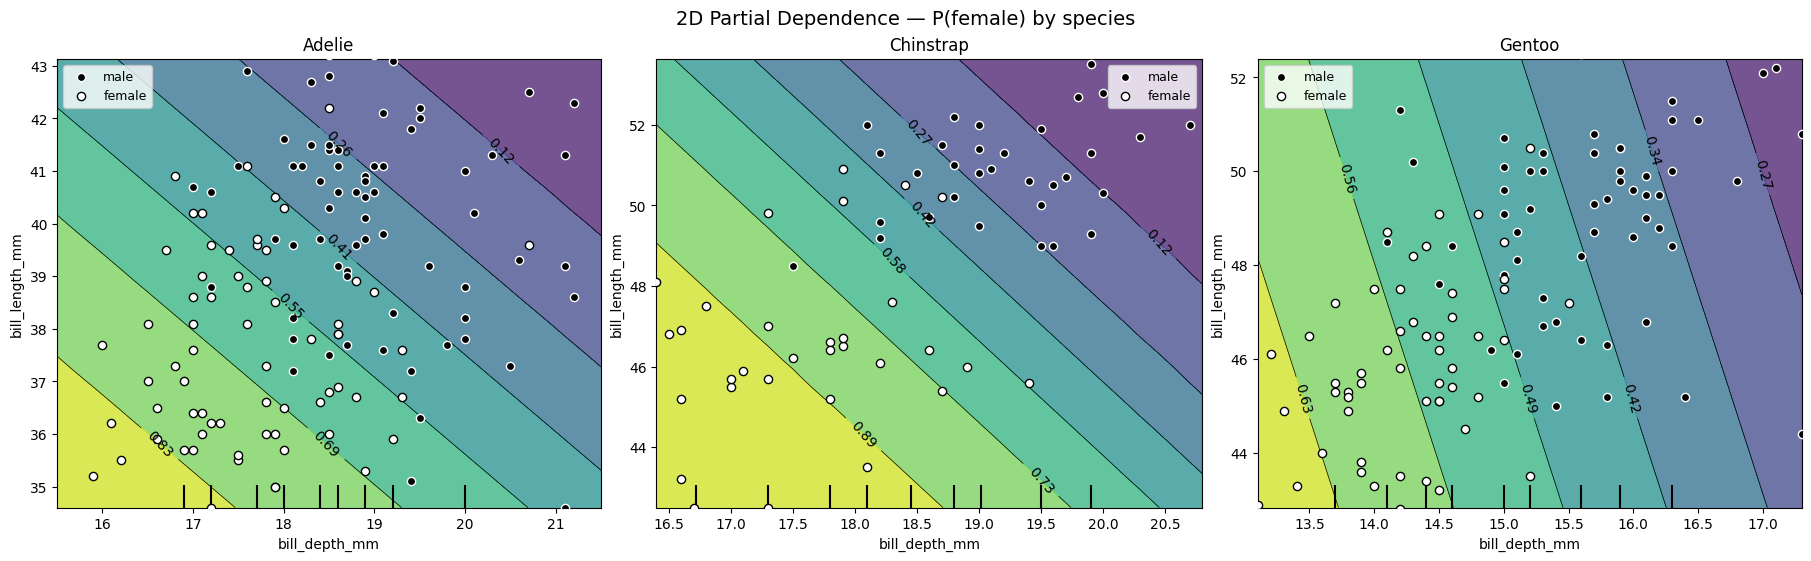

In [21]:
species_list = list(models.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

for ax, sp in zip(axes, species_list):
    model, X_sp = models[sp]
    disp = PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_sp,
        features=[("bill_depth_mm", "bill_length_mm")],
        kind="average",
        grid_resolution=50,
        ax=ax,
        contour_kw={"cmap": "viridis"},
    )

    # Grab the axes sklearn actually drew on (it replaces `ax` with its own)
    pdp_ax = disp.axes_[0, 0]

    sub = df[df["species"] == sp]
    male   = sub[sub["sex"] == 0]
    female = sub[sub["sex"] == 1]
    pdp_ax.scatter(male["bill_depth_mm"],   male["bill_length_mm"],
                   c="black", edgecolor="white", s=35, label="male", zorder=3)
    pdp_ax.scatter(female["bill_depth_mm"], female["bill_length_mm"],
                   c="white", edgecolor="black", s=35, label="female", zorder=3)

    pdp_ax.set_title(sp)
    pdp_ax.set_xlabel("bill_depth_mm")
    pdp_ax.set_ylabel("bill_length_mm")
    pdp_ax.legend(loc="best", fontsize=9)

fig.suptitle("2D Partial Dependence — P(female) by species", fontsize=14)
plt.show()